In [4]:
import numpy as np
from iminuit import Minuit
from iminuit.cost import LeastSquares
import matplotlib.pyplot as plt


In [5]:

# Generate some synthetic data
x = np.linspace(0, 10, 20)
y = 3.0 * x + 2.0 + np.random.normal(0, 1, size=x.size)  # true slope=3, intercept=2
yerr = np.ones_like(y)  # constant uncertainty

# Define model function
def model(x, m, c):
    return m * x + c

# Define cost function for least-squares
least_squares = LeastSquares(x, y, yerr, model)

# Initialize Minuit with starting values
m = Minuit(least_squares, m=1, c=0)

# Run minimization
m.migrad()  
m.hesse()   # estimate parameter uncertainties

# Print results
print(m.values)      # best-fit parameters
print(m.errors)      # parameter uncertainties


<ValueView m=2.959618949273427 c=1.822912974788041>
<ErrorView m=0.07367884742536765 c=0.4309458554877033>


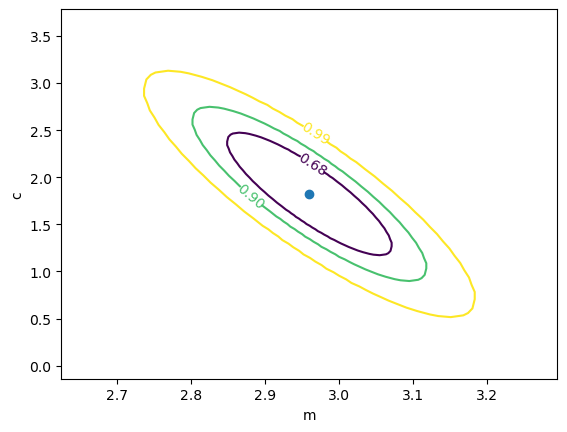

In [37]:
param1 = 'm'
param2 = 'c'

def zoom(factor=1.2):
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xmid = (xlim[0] + xlim[1]) / 2
    ymid = (ylim[0] + ylim[1]) / 2

    xsize = (xlim[1] - xlim[0]) * factor
    ysize = (ylim[1] - ylim[0]) * factor

    ax.set_xlim([xmid - xsize/2, xmid + xsize/2])
    ax.set_ylim([ymid - ysize/2, ymid + ysize/2])


m.draw_mncontour(param1, param2, cl = [0.68, 0.9, 0.99])
plt.plot(m.values[param1], m.values[param2], 'o')
zoom(1.5)   
plt.savefig(f'contour_{param1}_{param2}.pdf')

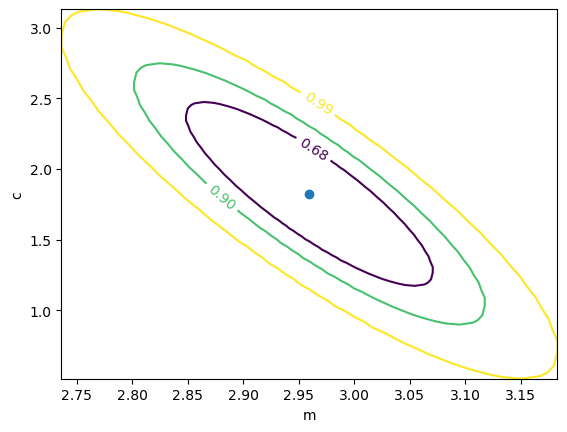

In [19]:
param1 = 'm'
param2 = 'c'

m.draw_mncontour(param1, param2, cl = [0.68, 0.9, 0.99])
plt.plot(m.values[param1], m.values[param2], 'o')
# plt.xlim(m.values[param1]*0.1, m.values[param1]*2)
# plt.ylim(m.values[param2]*0.1, m.values[param2]*2)
plt.savefig(f'contour_{param1}_{param2}.pdf')